# Model Training Notebook

Input feature file:

```text
/data/projects/TESS-research/feature_extraction/TESS_features.parquet
```

This notebook trains and evaluates:

1. Logistic Regression baseline
2. Random Forest model
3. Feature importance analysis
4. Final held-out test evaluation


## Step 0 — Imports and Configuration

### Goal
Load required Python libraries and define global configuration values.

### Logic
- Use pandas/numpy for data handling.
- Use scikit-learn for splitting, preprocessing, modeling, and evaluation.
- Set the extracted feature parquet as the input.
- Define the target label column as `family`.

### Expected Result
The notebook environment is ready, and all later cells use the same paths and random seed.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

FeaturePath = Path("/data/projects/TESS-research/feature_extraction/TESS_features.parquet")
OutputDir = Path("/data/projects/TESS-research/ml_analytics/outputs")
if not OutputDir.exists():
    OutputDir.mkdir(parents=True, exist_ok=True)

TargetColumn = "family"
StatusColumn = "FeatureStatus"
RandomState = 42


## Step 1 — Load Feature Table

### Goal
Load all extracted features from `TESS_features.parquet`.

### Logic
- Read the parquet file into a pandas DataFrame.
- Display the shape and the first few rows.

### Expected Result
You should see approximately one row per successfully processed target plus some rows with non-OK status, depending on the feature extraction output.


In [15]:
FeatureDf = pd.read_parquet(FeaturePath)

print(f"Loaded feature table: {FeatureDf.shape[0]} rows, {FeatureDf.shape[1]} columns")
display(FeatureDf.head())


Loaded feature table: 7370 rows, 67 columns


,FeatureStatus,FeatureError,family,VSXType,VSXId,lightCurvePath,rawLightCurvePath,QualityLabel,QualityScore,Provenance,ProvenanceScore,OriginalFluxMedian,OriginalFluxStd,OriginalFluxSnr,LowSnr,LowQualityLightCurve,CadenceCount,TimeSpanDays,MedianCadenceDays,FluxMean,FluxStd,FluxVariance,FluxMedian,FluxMad,FluxMin,FluxMax,FluxP01,FluxP05,FluxP10,FluxP25,FluxP75,FluxP90,FluxP95,FluxP99,FluxIqr,FluxAmplitude,FluxPercentAmplitude95To5,FluxPercentAmplitude90To10,FluxSkewness,FluxKurtosis,TailUpper,TailLower,TailAsymmetry,TailRatio,EtaVonNeumann,MaxAbsSlope,MedianAbsSuccessiveDiff,FractionBeyond1Std,FractionBeyond2Std,LsBestPeriod,LsBestFrequency,LsMaxPower,LsFalseAlarmProbability,LsPeriod2,LsPeriod3,LsPower2,LsPower3,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,PhaseCurveStd,PhaseCurveRange,PhaseCurveSmoothness,PhasePeakPhase,PhaseTroughPhase,PhasePeakToTroughPhaseDelta
0,ok,NaN,CEPHEID,DCEP,LMC V0827,TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_s...,TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_r...,acceptable,1,TESSCut,2.0,1.0,1.074691,0.930500,True,True,293319.0,2720.548082,0.002315,0.182296,1.0,1.0,0.0,0.014218,-8.059426,21.666578,-2.226746,-0.421401,-0.050117,-0.007363,0.106323,0.699204,1.603927,4.048967,0.113686,29.726005,2.025327,0.749321,5.143412,72.580950,1.603927,0.421401,1.182526,3.806182,0.461728,5234.501410,0.002714,0.101613,0.048258,13.908343,0.071899,0.022761,0.0,13.901236,13.588779,0.022426,0.021828,0.985314,0.959047,0.999489,0.977024,0.001356,0.004517,0.000794,0.024824,0.674974,0.349851
1,ok,NaN,CEPHEID,DCEP,OGLE-GD-CEP-0948,TESSCache/VSX_OGLE-GD-CEP-0948_TIC_321957546_S...,TESSCache/VSX_OGLE-GD-CEP-0948_TIC_321957546_S...,clean,0,SPOC,0.0,1.0,0.523226,1.911220,True,True,17563.0,25.968380,0.001389,-0.380000,1.0,1.0,0.0,0.233236,-4.275680,0.817094,-3.834142,-3.175055,-1.844262,-0.474010,0.180536,0.300452,0.371343,0.493608,0.654547,5.092774,3.546398,2.144714,-2.173310,3.958710,0.371343,3.175055,-2.803712,0.116957,0.023459,454.889912,0.103308,0.119683,0.080339,0.477262,2.095283,0.446469,0.0,0.478141,0.476387,0.445210,0.418312,0.997181,0.936934,1.001841,0.998166,0.763762,3.282615,0.663933,0.025031,0.525033,0.499998
2,ok,NaN,CEPHEID,DCEP,ZTF J212148.91+495425.9,TESSCache/VSX_ZTF_J212148.91+495425.9_TIC_6371...,TESSCache/VSX_ZTF_J212148.91+495425.9_TIC_6371...,clean,0,QLP,1.0,1.0,0.159239,6.279885,False,False,23557.0,1872.992754,0.002315,0.116037,1.0,1.0,0.0,0.684947,-5.538392,19.473658,-1.870420,-1.289458,-1.022799,-0.617110,0.801940,1.448831,1.780007,2.472434,1.419051,25.012050,3.069465,2.471630,0.960073,9.369394,1.780007,1.289458,0.490549,1.380431,0.195581,5062.259858,0.227117,0.312221,0.032772,3.876789,0.257945,0.540867,0.0,3.884830,3.868781,0.539933,0.536160,0.998273,0.991298,1.002074,0.997934,0.798071,2.406318,0.331279,0.824615,0.625010,0.199605
3,missing_lightcurve_path,No lightCurvePath,CEPHEID,DCEP,Gaia DR3 4687498277203934336,NaN,NaN,missing,4,missing,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,missing_lightcurve_path,No lightCurvePath,CEPHEID,DCEP,Gaia DR3 4687206593067239808,NaN,NaN,missing,4,missing,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 2 — Check Feature Extraction Status

### Goal
Confirm which rows are usable for model training.

### Logic
- Count values in `FeatureStatus`.
- Keep only rows where `FeatureStatus == "ok"`.
- Drop rows with missing target label.

### Expected Result
Most rows should be `ok`. Rows with `missing_lightcurve_path` or failed extraction should be excluded from modeling.


In [16]:
if StatusColumn in FeatureDf.columns:
    display(FeatureDf[StatusColumn].value_counts(dropna=False))
    ModelDf = FeatureDf[FeatureDf[StatusColumn] == "ok"].copy()
else:
    print(f"Warning: {StatusColumn} not found; using all rows.")
    ModelDf = FeatureDf.copy()

ModelDf = ModelDf.dropna(subset=[TargetColumn]).copy()

print(f"Rows available for modeling: {len(ModelDf)}")
display(ModelDf[TargetColumn].value_counts())


FeatureStatus
ok                         7113
missing_lightcurve_path     257
Name: count, dtype: int64

Rows available for modeling: 7113


family
ELLIPSOIDAL_ROT    997
ECLIPSING          996
LONG_PERIOD        980
RRLYR              976
DSCT_SXPHE         953
CEPHEID            836
YSO                724
CV                 595
XRAY                56
Name: count, dtype: int64

## Step 3 — Select Feature Columns

### Goal
Create the input matrix `X` using only model-safe numeric features.

### Logic
- Exclude target labels, file paths, object identifiers, text columns, and status columns.
- Use numeric and boolean columns only.
- Keep physically meaningful feature columns such as Lomb-Scargle, flux statistics, variability, phase, and QC numeric fields.

### Expected Result
A list of selected model input features is displayed. The number should be much smaller than the full DataFrame column count.


In [17]:
ExcludeColumns = {
    TargetColumn,
    StatusColumn,
    "FeatureError",
    "Name",
    "VSXId",
    "VSXType",
    "ticId",
    "bestTicId",
    "lightCurvePath",
    "rawLightCurvePath",
    "QualityLabel",
    "Provenance",
}

NumericColumns = ModelDf.select_dtypes(include=[np.number, bool]).columns.tolist()

FeatureColumns = [
    Col for Col in NumericColumns
    if Col not in ExcludeColumns
]

print(f"Selected {len(FeatureColumns)} numeric feature columns.")
display(pd.DataFrame({"FeatureColumn": FeatureColumns}))


Selected 58 numeric feature columns.


,FeatureColumn
0,QualityScore
1,ProvenanceScore
2,OriginalFluxMedian
3,OriginalFluxStd
4,OriginalFluxSnr
5,LowSnr
6,LowQualityLightCurve
7,CadenceCount
8,TimeSpanDays
9,MedianCadenceDays


## Step 4 — Inspect Missing Values

### Goal
Understand which features contain missing values before modeling.

### Logic
- Compute missing-value rate for each selected feature.
- Sort features by missing rate.
- Later model pipelines will impute missing values using the training set only.

### Expected Result
Some missing values are normal, especially for period or phase features when a reliable period cannot be estimated.


In [18]:
MissingRate = ModelDf[FeatureColumns].isna().mean().sort_values(ascending=False)
display(MissingRate.head(40))


QualityScore                  0.0
LsFalseAlarmProbability       0.0
TailUpper                     0.0
TailLower                     0.0
TailAsymmetry                 0.0
TailRatio                     0.0
EtaVonNeumann                 0.0
MaxAbsSlope                   0.0
MedianAbsSuccessiveDiff       0.0
FractionBeyond1Std            0.0
FractionBeyond2Std            0.0
LsBestPeriod                  0.0
LsBestFrequency               0.0
LsMaxPower                    0.0
LsPeriod2                     0.0
ProvenanceScore               0.0
LsPeriod3                     0.0
LsPower2                      0.0
LsPower3                      0.0
LsPowerRatio21                0.0
LsPowerRatio31                0.0
LsPeriodRatio21               0.0
LsPeriodRatio31               0.0
PhaseCurveStd                 0.0
PhaseCurveRange               0.0
PhaseCurveSmoothness          0.0
PhasePeakPhase                0.0
PhaseTroughPhase              0.0
FluxKurtosis                  0.0
FluxSkewness  

## Step 5 — Train / Validation / Test Split

### Goal
Separate data into training, validation, and test sets.

### Logic
- Use stratified split by `family`.
- Use 70% training, 15% validation, 15% test.
- Do this before fitting scalers, imputers, or models.

### Expected Result
The class distribution should be similar across train, validation, and test sets.


In [19]:
TrainDf, TempDf = train_test_split(
    ModelDf,
    test_size=0.30,
    stratify=ModelDf[TargetColumn],
    random_state=RandomState,
)

ValDf, TestDf = train_test_split(
    TempDf,
    test_size=0.50,
    stratify=TempDf[TargetColumn],
    random_state=RandomState,
)

XTrain = TrainDf[FeatureColumns]
yTrain = TrainDf[TargetColumn]

XVal = ValDf[FeatureColumns]
yVal = ValDf[TargetColumn]

XTest = TestDf[FeatureColumns]
yTest = TestDf[TargetColumn]

print("Train:", XTrain.shape)
print("Validation:", XVal.shape)
print("Test:", XTest.shape)

display(pd.DataFrame({
    "Train": yTrain.value_counts(),
    "Validation": yVal.value_counts(),
    "Test": yTest.value_counts(),
}).fillna(0).astype(int))


Train: (4979, 58)
Validation: (1067, 58)
Test: (1067, 58)


,Train,Validation,Test
family,,,
CEPHEID,585,126,125
CV,417,89,89
DSCT_SXPHE,667,143,143
ECLIPSING,697,150,149
ELLIPSOIDAL_ROT,698,149,150
LONG_PERIOD,686,147,147
RRLYR,683,146,147
XRAY,39,8,9
YSO,507,109,108


## Step 6 — Train Logistic Regression Baseline

### Goal
Train a simple baseline classifier.

### Logic
- Impute missing values using median values from training data.
- Standardize features because Logistic Regression is scale-sensitive.
- Use class balancing because family counts may not be equal.
- Evaluate on validation set.

### Expected Result
This gives a baseline validation accuracy and balanced accuracy. It also provides per-family precision, recall, and F1 scores.


In [20]:
LogisticModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RandomState,
        )),
    ]
)

LogisticModel.fit(XTrain, yTrain)
LogisticValPred = LogisticModel.predict(XVal)

LogisticValAccuracy = accuracy_score(yVal, LogisticValPred)
LogisticValBalancedAccuracy = balanced_accuracy_score(yVal, LogisticValPred)

print("Logistic Regression Validation Accuracy:", LogisticValAccuracy)
print("Logistic Regression Validation Balanced Accuracy:", LogisticValBalancedAccuracy)
print()
print(classification_report(yVal, LogisticValPred))


Logistic Regression Validation Accuracy: 0.3908153701968135
Logistic Regression Validation Balanced Accuracy: 0.4000560351183083

                 precision    recall  f1-score   support

        CEPHEID       0.40      0.40      0.40       126
             CV       0.22      0.22      0.22        89
     DSCT_SXPHE       0.48      0.37      0.42       143
      ECLIPSING       0.33      0.27      0.30       150
ELLIPSOIDAL_ROT       0.40      0.22      0.29       149
    LONG_PERIOD       0.70      0.61      0.65       147
          RRLYR       0.28      0.45      0.34       146
           XRAY       0.06      0.50      0.11         8
            YSO       0.57      0.54      0.55       109

       accuracy                           0.39      1067
      macro avg       0.38      0.40      0.37      1067
   weighted avg       0.43      0.39      0.40      1067



## Step 7 — Train Random Forest Model

### Goal
Train a nonlinear model that can capture feature interactions.

### Logic
- Impute missing values using median values from training data.
- Do not standardize, because tree-based models do not require scaling.
- Use many trees for stable estimates.
- Use class-balanced subsampling to reduce class imbalance effects.
- Evaluate on validation set.

### Expected Result
Random Forest should ideally improve over Logistic Regression, especially if nonlinear relationships exist among period, amplitude, morphology, and variability features.


In [21]:
RandomForestModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RandomState,
        )),
    ]
)

RandomForestModel.fit(XTrain, yTrain)
RandomForestValPred = RandomForestModel.predict(XVal)

RandomForestValAccuracy = accuracy_score(yVal, RandomForestValPred)
RandomForestValBalancedAccuracy = balanced_accuracy_score(yVal, RandomForestValPred)

print("Random Forest Validation Accuracy:", RandomForestValAccuracy)
print("Random Forest Validation Balanced Accuracy:", RandomForestValBalancedAccuracy)
print()
print(classification_report(yVal, RandomForestValPred))


Random Forest Validation Accuracy: 0.5295220243673852
Random Forest Validation Balanced Accuracy: 0.46642747674197743

                 precision    recall  f1-score   support

        CEPHEID       0.70      0.56      0.62       126
             CV       0.44      0.30      0.36        89
     DSCT_SXPHE       0.50      0.59      0.54       143
      ECLIPSING       0.41      0.45      0.43       150
ELLIPSOIDAL_ROT       0.49      0.42      0.45       149
    LONG_PERIOD       0.67      0.77      0.72       147
          RRLYR       0.39      0.53      0.45       146
           XRAY       0.00      0.00      0.00         8
            YSO       0.83      0.58      0.68       109

       accuracy                           0.53      1067
      macro avg       0.49      0.47      0.47      1067
   weighted avg       0.54      0.53      0.53      1067



## Step 8 — Compare Validation Performance

### Goal
Compare the simple baseline and Random Forest on the same validation set.

### Logic
- Put validation accuracy and balanced accuracy into a compact table.
- Use balanced accuracy as an important metric because family counts may differ.

### Expected Result
If Random Forest is meaningfully better, it supports using a nonlinear model for the next phase.


In [22]:
ComparisonDf = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "ValidationAccuracy": LogisticValAccuracy,
            "ValidationBalancedAccuracy": LogisticValBalancedAccuracy,
        },
        {
            "Model": "Random Forest",
            "ValidationAccuracy": RandomForestValAccuracy,
            "ValidationBalancedAccuracy": RandomForestValBalancedAccuracy,
        },
    ]
)

display(ComparisonDf)


,Model,ValidationAccuracy,ValidationBalancedAccuracy
0,Logistic Regression,0.390815,0.400056
1,Random Forest,0.529522,0.466427


## Step 9 — Confusion Matrix

### Goal
Identify which star families are confused by the Random Forest model.

### Logic
- Compute confusion matrix on the validation set.
- Rows represent true labels.
- Columns represent predicted labels.
- Display both table and heatmap.

### Expected Result
This should reveal difficult class pairs, such as families with similar periods, amplitudes, or morphology.


,CEPHEID,CV,DSCT_SXPHE,ECLIPSING,ELLIPSOIDAL_ROT,LONG_PERIOD,RRLYR,XRAY,YSO
CEPHEID,71,10,7,6,7,6,13,1,5
CV,5,27,16,15,2,1,21,0,2
DSCT_SXPHE,2,6,84,10,6,12,21,0,2
ECLIPSING,0,2,14,67,26,7,32,0,2
ELLIPSOIDAL_ROT,7,2,10,38,63,9,20,0,0
LONG_PERIOD,6,6,3,2,5,113,11,0,1
RRLYR,7,4,19,19,13,7,77,0,0
XRAY,1,2,0,0,3,0,1,0,1
YSO,3,2,14,6,3,14,2,2,63


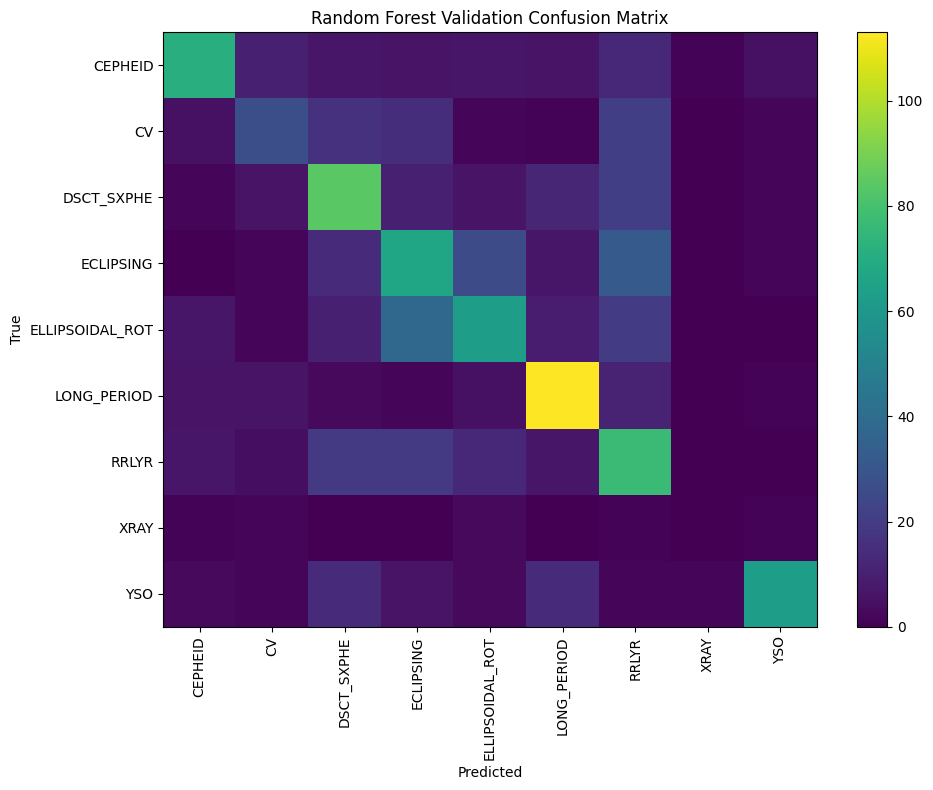

In [23]:
Labels = sorted(yVal.unique())

ConfMat = confusion_matrix(yVal, RandomForestValPred, labels=Labels)
ConfMatDf = pd.DataFrame(ConfMat, index=Labels, columns=Labels)

display(ConfMatDf)

plt.figure(figsize=(10, 8))
plt.imshow(ConfMat, aspect="auto")
plt.xticks(range(len(Labels)), Labels, rotation=90)
plt.yticks(range(len(Labels)), Labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Validation Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 10 — Feature Importance

### Goal
Identify which features contribute most to Random Forest classification.

### Logic
- Extract feature importance from the trained Random Forest.
- Rank features from most to least important.
- Plot top features.

### Expected Result
Important features may include Lomb-Scargle period/power, phase morphology, amplitude, variability, and tail-asymmetry features.


,Feature,Importance
8,TimeSpanDays,0.037459
35,EtaVonNeumann,0.031523
7,CadenceCount,0.029909
3,OriginalFluxStd,0.026737
4,OriginalFluxSnr,0.026613
45,LsPeriod3,0.026094
36,MaxAbsSlope,0.026075
40,LsBestPeriod,0.025335
41,LsBestFrequency,0.025319
37,MedianAbsSuccessiveDiff,0.025010


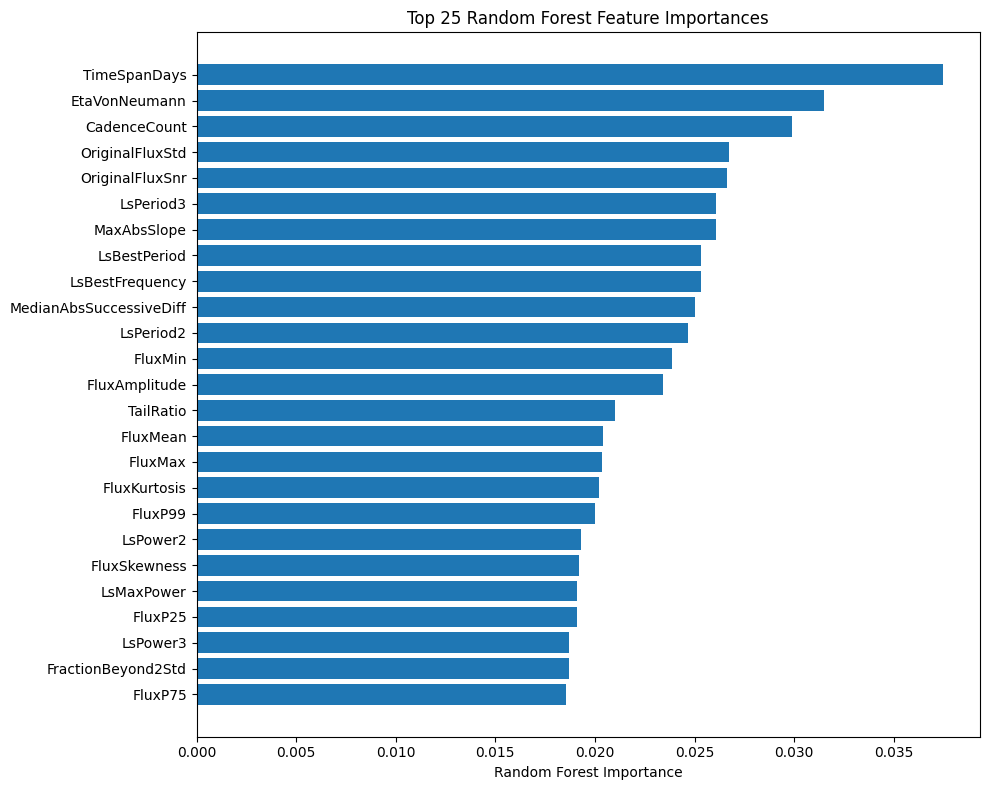

In [24]:
RfClassifier = RandomForestModel.named_steps["model"]

ImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "Importance": RfClassifier.feature_importances_,
}).sort_values("Importance", ascending=False)

display(ImportanceDf.head(30))

TopN = 25
TopImportance = ImportanceDf.head(TopN).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(TopImportance["Feature"], TopImportance["Importance"])
plt.xlabel("Random Forest Importance")
plt.title(f"Top {TopN} Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## Step 11 — Final Test Evaluation

### Goal
Evaluate the selected Random Forest model on the held-out test set.

### Logic
- Use the trained Random Forest pipeline.
- Predict labels for the test set.
- Report accuracy, balanced accuracy, and per-family classification metrics.

### Expected Result
This gives the final held-out performance estimate. Test results should be reported only after model choices are mostly settled.


In [25]:
RandomForestTestPred = RandomForestModel.predict(XTest)

RandomForestTestAccuracy = accuracy_score(yTest, RandomForestTestPred)
RandomForestTestBalancedAccuracy = balanced_accuracy_score(yTest, RandomForestTestPred)

print("Random Forest Test Accuracy:", RandomForestTestAccuracy)
print("Random Forest Test Balanced Accuracy:", RandomForestTestBalancedAccuracy)
print()
print(classification_report(yTest, RandomForestTestPred))


Random Forest Test Accuracy: 0.5267104029990628
Random Forest Test Balanced Accuracy: 0.48732476057211077

                 precision    recall  f1-score   support

        CEPHEID       0.63      0.55      0.59       125
             CV       0.36      0.25      0.29        89
     DSCT_SXPHE       0.46      0.52      0.49       143
      ECLIPSING       0.40      0.44      0.42       149
ELLIPSOIDAL_ROT       0.50      0.41      0.45       150
    LONG_PERIOD       0.66      0.82      0.73       147
          RRLYR       0.43      0.52      0.47       147
           XRAY       0.50      0.22      0.31         9
            YSO       0.83      0.66      0.73       108

       accuracy                           0.53      1067
      macro avg       0.53      0.49      0.50      1067
   weighted avg       0.53      0.53      0.52      1067



## Step 12 — Save Useful Outputs

### Goal
Save key outputs for later reporting and paper-writing.

### Logic
- Save model comparison table.
- Save feature importance table.
- Save validation confusion matrix.

### Expected Result
CSV files are created next to the input feature file.


In [26]:
ComparisonPath = OutputDir / "model_comparison_validation.csv"
ImportancePath = OutputDir / "random_forest_feature_importance.csv"
ConfusionPath = OutputDir / "random_forest_validation_confusion_matrix.csv"

ComparisonDf.to_csv(ComparisonPath, index=False)
ImportanceDf.to_csv(ImportancePath, index=False)
ConfMatDf.to_csv(ConfusionPath)

print("Saved:")
print(ComparisonPath)
print(ImportancePath)
print(ConfusionPath)


OSError: Cannot save file into a non-existent directory: '/data/projects/TESS-research/ml_analytics/outputs'

## Step 13 — Recommended Follow-Up Checks

### Goal
Decide what to investigate after the first model run.

### Logic
Review:

- whether Random Forest clearly improves over Logistic Regression
- which families have low recall
- which families are confused
- whether metadata/QC features dominate feature importance
- whether tail-asymmetry features help

### Expected Result
This should guide the next experiment, such as feature ablation, hyperparameter tuning, or per-family error analysis.
